In [3]:
!pip install numpy pandas matplotlib scipy

/Users/arjunaji/BIA ARJUN/my_env/bin/pip: line 2: /Users/arjunaji/BIA ARJUN/vs/my_env/bin/python: No such file or directory
/Users/arjunaji/BIA ARJUN/my_env/bin/pip: line 2: exec: /Users/arjunaji/BIA ARJUN/vs/my_env/bin/python: cannot execute: No such file or directory


In [4]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option('display.precision', 3)
print("setup complete")


setup complete


In [5]:
employee_data = pd.DataFrame({
    "department": ["HR", "IT", "Finance", "Marketing", "Sales"],
    "satisfation":["Low", "Medium", "High", "Low", "Medium"],
    "projects_completed": [5, 10, 15, 7, 12],
    "monthly_hours": [160, 180, 200, 170, 190]
}
)
display(employee_data)

,department,satisfation,projects_completed,monthly_hours
0,HR,Low,5,160
1,IT,Medium,10,180
2,Finance,High,15,200
3,Marketing,Low,7,170
4,Sales,Medium,12,190


In [6]:
type(employee_data)

pandas.DataFrame

In [7]:
employee_data.dtypes

department              str
satisfation             str
projects_completed    int64
monthly_hours         int64
dtype: object

In [8]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   department          5 non-null      str  
 1   satisfation         5 non-null      str  
 2   projects_completed  5 non-null      int64
 3   monthly_hours       5 non-null      int64
dtypes: int64(2), str(2)
memory usage: 292.0 bytes


In [9]:
employee_data["department"]=employee_data["department"].astype("category")

In [10]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   department          5 non-null      category
 1   satisfation         5 non-null      str     
 2   projects_completed  5 non-null      int64   
 3   monthly_hours       5 non-null      int64   
dtypes: category(1), int64(2), str(1)
memory usage: 297.0 bytes


In [11]:
employee_data["satisfation"]= pd.Categorical(employee_data["satisfation"], categories=["Low", "Medium", "High"], ordered=True)

In [12]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   department          5 non-null      category
 1   satisfation         5 non-null      category
 2   projects_completed  5 non-null      int64   
 3   monthly_hours       5 non-null      int64   
dtypes: category(2), int64(2)
memory usage: 394.0 bytes


# MEAN,MEDIAN,MODE

In [13]:
population_size = 100000
population_income=rng.lognormal(mean=np.log(50000), sigma=0.45, size=population_size)
population_income

array([57348.44283916, 31312.90013794, 70086.20914671, ...,
       98342.12485416, 46667.74726876, 67127.16715971], shape=(100000,))

In [14]:
population_mean = population_income.mean()
population_mean
sample=rng.choice(population_income, size=100, replace=False)
sample_mean=sample.mean()

print(f"Population mean: {population_mean:.0f}")
print(f"Sample mean: {sample_mean:.0f}")
print(f"Sampling error: {sample_mean - population_mean:.0f}")

Population mean: 55272
Sample mean: 56650
Sampling error: 1378


In [15]:
sample_mean=sample.mean()
print(f"Sample mean: {sample_mean:.0f}")
sample_median=np.median(sample)
print(f"Sample median: {sample_median:.0f}")
sample_mode=stats.mode(sample, keepdims=True).mode[0]
print(f"Sample mode: {sample_mode:.0f}")

Sample mean: 56650
Sample median: 50885
Sample mode: 18695


In [16]:
base_values=np.array([10, 20, 30, 40, 50])
with_outlies=np.append(base_values,200)
base_mean=base_values.mean()
base_median=np.median(base_values)
outlier_mean=with_outlies.mean()
outlier_median=np.median(with_outlies)
print(f"Base Values: {base_values}")
print(f"Base mean: {base_mean:.2f}")
print(f"Base median: {base_median:.2f}")
print(f"With Outlier: {with_outlies}")
print(f"Outlier mean: {outlier_mean:.2f}")
print(f"Outlier median: {outlier_median:.2f}")

Base Values: [10 20 30 40 50]
Base mean: 30.00
Base median: 30.00
With Outlier: [ 10  20  30  40  50 200]
Outlier mean: 58.33
Outlier median: 35.00


/var/folders/kw/f9zhtdmd7gj6psdg7h6wjqwc0000gn/T/ipykernel_9802/1525668760.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(sample, vert=False)


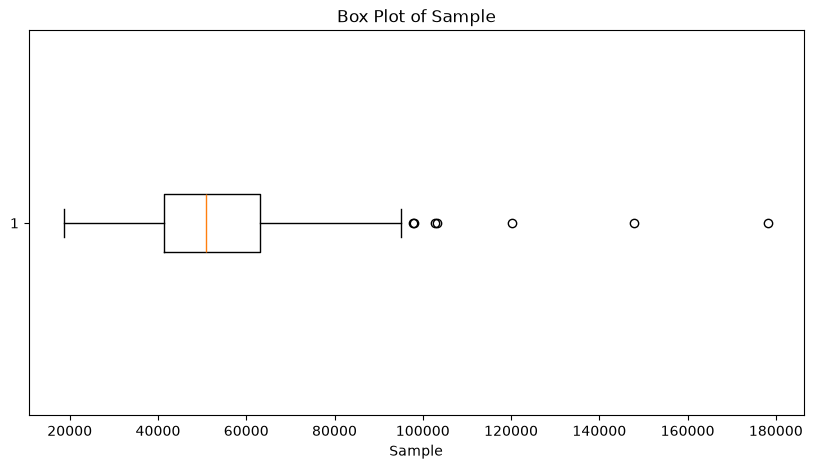

In [17]:
plt.figure(figsize=(10, 5))
plt.boxplot(sample, vert=False)
plt.xlabel("Sample")
plt.title("Box Plot of Sample")
plt.show()  

# STANDARD DEVIATION

In [18]:
print(f"Base Values: {base_values}")
print(f"Base Standard Deviation: {base_values.std():.2f}"   )

Base Values: [10 20 30 40 50]
Base Standard Deviation: 14.14


# IQR

In [23]:
low_spread=np.array([10, 12, 11, 13, 12])
high_spread=np.array([5, 15, 10, 20, 25])

def dispersion_summary(values):
    '''return common dispersion statistics for a numerical array'''
    q1=np.percentile(values, 25)
    q3=np.percentile(values, 75)
    return pd.Series({
        "mean":np.mean(values),
        "range":np.ptp(values),
        "variance":np.var(values, ddof=1),
        "std_dev":np.std(values, ddof=1),
        "IQR":q3-q1,
    })
disp_summary=pd.DataFrame({
    "Low Spread":dispersion_summary(low_spread),
    "High Spread":dispersion_summary(high_spread)
}).round(2)
display(disp_summary)

,Low Spread,High Spread
mean,11.60,15.00
range,3.00,20.00
variance,1.30,62.50
std_dev,1.14,7.91
IQR,1.00,10.00


In [24]:
iqr = stats.iqr(low_spread)
print(f"Interquartile Range (IQR) of the low spread data: {iqr:.2f}")

Interquartile Range (IQR) of the low spread data: 1.00


In [25]:
iqr = stats.iqr(high_spread)
print(f"Interquartile Range (IQR) of the high spread data: {iqr:.2f}")

Interquartile Range (IQR) of the high spread data: 10.00
